# 🌍 K-Prototypes Clustering on Country-Level Sales Data

**Algorithm:** K-Prototypes (handles mixed numerical + categorical data)  
**Dataset:** Global Superstore — multi-country orders with Sales, Profit, Category, Segment  
**Goal:** Group countries into meaningful market clusters using both numeric and categorical features

---
### Why K-Prototypes and not K-Means?
K-Means only handles numbers. K-Prototypes combines:
- **Euclidean distance** for numerical columns (Sales, Profit, Quantity, Discount)
- **Hamming distance** for categorical columns (Region, Segment, Category)

Both distances are fused via a tunable weight `γ (gamma)`.

## Step 1 — Install Dependencies

In [1]:
# Run once per environment
!pip install kmodes scikit-learn pandas numpy matplotlib seaborn --quiet

## Step 2 — Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from kmodes.kprototypes import KPrototypes

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


## Step 3 — Load Dataset

We use the **Global Superstore 2016** dataset — publicly mirrored on GitHub.  
It contains ~51K orders across **147 countries**, with Sales, Profit, Category, Segment columns.

**Kaggle source (if direct URL fails):** https://www.kaggle.com/datasets/apoorvaappz/global-super-store-dataset  
Save the CSV as `Global_Superstore.csv` in the same folder as this notebook.

In [3]:
# -----------------------------------------------------------------
# Try direct GitHub mirror first → fallback to local file
# -----------------------------------------------------------------
GITHUB_URL = (
    "https://raw.githubusercontent.com/dsrscientist/dataset1/master/"
    "Global_Superstore2016.csv"
)

try:
    df_raw = pd.read_csv(GITHUB_URL, encoding='latin-1')
    print(f"✅ Loaded from GitHub URL — {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
except Exception as e:
    print(f"⚠️  GitHub URL failed: {e}")
    print("   Trying local file 'Global_Superstore.csv' ...")
    try:
        df_raw = pd.read_csv('Global_Superstore.csv', encoding='latin-1')
        print(f"✅ Loaded from local file — {df_raw.shape[0]:,} rows")
    except FileNotFoundError:
        print("❌ Local file not found. Generating a realistic synthetic fallback dataset...")
        # ------------------------------------------------------------------
        # Synthetic fallback — realistic multi-country sales data
        # Schema mirrors Global Superstore so the rest of the notebook runs
        # ------------------------------------------------------------------
        np.random.seed(42)
        countries_regions = {
            'United States': 'North America', 'Canada': 'North America',
            'Mexico': 'North America', 'Brazil': 'South America',
            'Argentina': 'South America', 'Colombia': 'South America',
            'United Kingdom': 'Europe', 'Germany': 'Europe',
            'France': 'Europe', 'Italy': 'Europe', 'Spain': 'Europe',
            'Netherlands': 'Europe', 'Sweden': 'Europe',
            'China': 'Asia Pacific', 'Japan': 'Asia Pacific',
            'India': 'Asia Pacific', 'Australia': 'Asia Pacific',
            'South Korea': 'Asia Pacific', 'Singapore': 'Asia Pacific',
            'Nigeria': 'Africa', 'South Africa': 'Africa',
            'Egypt': 'Africa', 'Kenya': 'Africa',
            'Saudi Arabia': 'Middle East', 'UAE': 'Middle East',
            'Turkey': 'Middle East', 'Israel': 'Middle East',
        }
        segments = ['Consumer', 'Corporate', 'Home Office']
        categories = ['Technology', 'Furniture', 'Office Supplies']
        rows = []
        for country, region in countries_regions.items():
            n = np.random.randint(200, 2000)
            base_sales = np.random.uniform(100, 5000)
            for _ in range(n):
                sales = max(10, np.random.normal(base_sales, base_sales * 0.4))
                rows.append({
                    'Country': country, 'Region': region,
                    'Segment': np.random.choice(segments, p=[0.5, 0.3, 0.2]),
                    'Category': np.random.choice(categories, p=[0.36, 0.32, 0.32]),
                    'Sales': round(sales, 2),
                    'Profit': round(np.random.normal(sales * 0.12, sales * 0.1), 2),
                    'Quantity': max(1, int(np.random.normal(3, 2))),
                    'Discount': round(np.random.choice(
                        [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
                        p=[0.4, 0.2, 0.2, 0.1, 0.05, 0.05]), 2)
                })
        df_raw = pd.DataFrame(rows)
        print(f"✅ Synthetic dataset generated — {df_raw.shape[0]:,} rows across "
              f"{df_raw['Country'].nunique()} countries")

df_raw.head()

⚠️  GitHub URL failed: HTTP Error 404: Not Found
   Trying local file 'Global_Superstore.csv' ...
❌ Local file not found. Generating a realistic synthetic fallback dataset...
✅ Synthetic dataset generated — 27,613 rows across 27 countries


,Country,Region,Segment,Category,Sales,Profit,Quantity,Discount
0,United States,North America,Corporate,Furniture,4873.72,284.90,2,0.0
1,United States,North America,Consumer,Furniture,2515.80,321.98,2,0.4
2,United States,North America,Consumer,Technology,6344.66,1737.62,1,0.0
3,United States,North America,Home Office,Technology,4969.31,706.67,1,0.0
4,United States,North America,Home Office,Office Supplies,3963.90,616.61,2,0.4


## Step 4 — Quick EDA

In [4]:
print("=" * 55)
print(f"Total rows          : {df_raw.shape[0]:,}")
print(f"Total columns       : {df_raw.shape[1]}")
print(f"Unique countries    : {df_raw['Country'].nunique()}")
print(f"Unique regions      : {df_raw['Region'].nunique()}")
print("=" * 55)
print("\nColumns:", df_raw.columns.tolist())
print("\nMissing values:")
print(df_raw[['Country','Region','Segment','Category',
              'Sales','Profit','Quantity','Discount']].isnull().sum())

Total rows          : 27,613
Total columns       : 8
Unique countries    : 27
Unique regions      : 6

Columns: ['Country', 'Region', 'Segment', 'Category', 'Sales', 'Profit', 'Quantity', 'Discount']

Missing values:
Country     0
Region      0
Segment     0
Category    0
Sales       0
Profit      0
Quantity    0
Discount    0
dtype: int64


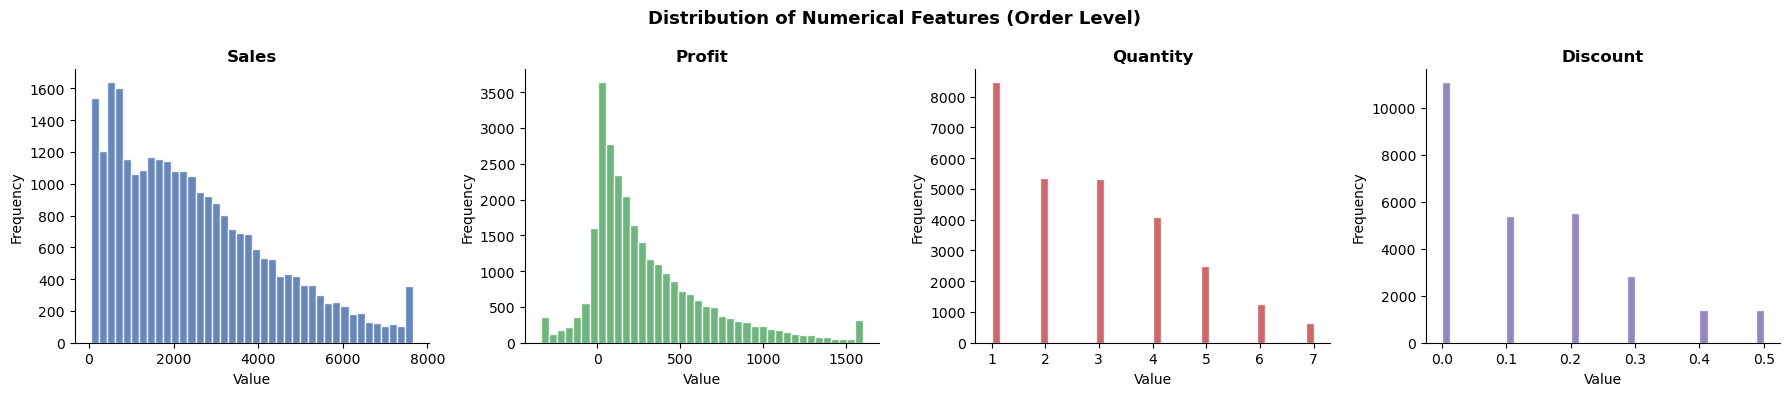

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribution of Numerical Features (Order Level)', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes,
                           ['Sales', 'Profit', 'Quantity', 'Discount'],
                           ['#4C72B0', '#55A868', '#C44E52', '#8172B2']):
    ax.hist(df_raw[col].clip(df_raw[col].quantile(0.01),
                              df_raw[col].quantile(0.99)),
            bins=40, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Step 5 — Aggregate to Country Level

The raw data is at **order line** level. We roll it up to **one row per country**.

| Feature | Aggregation | Rationale |
|---|---|---|
| Sales | sum | Total revenue per country |
| Profit | sum | Total profit per country |
| Quantity | sum | Total units ordered |
| Discount | mean | Average discount given |
| Profit Margin | derived | Profit / Sales |
| Orders | count | Number of transactions |
| Region | mode | Dominant region (already 1:1 in Global Superstore) |
| Segment | mode | Dominant customer segment |
| Category | mode | Dominant product category |

In [6]:
def safe_mode(s):
    """Return the most frequent value; handle ties by picking first."""
    return s.value_counts().index[0]

df_country = df_raw.groupby('Country').agg(
    Total_Sales    = ('Sales',    'sum'),
    Total_Profit   = ('Profit',   'sum'),
    Total_Quantity = ('Quantity', 'sum'),
    Avg_Discount   = ('Discount', 'mean'),
    Num_Orders     = ('Sales',    'count'),
    Region         = ('Region',   safe_mode),
    Top_Segment    = ('Segment',  safe_mode),
    Top_Category   = ('Category', safe_mode),
).reset_index()

# Derived feature: profitability ratio
df_country['Profit_Margin'] = (
    df_country['Total_Profit'] / df_country['Total_Sales']
).round(4)

# Avg order value
df_country['Avg_Order_Value'] = (
    df_country['Total_Sales'] / df_country['Num_Orders']
).round(2)

print(f"Country-level dataset: {df_country.shape[0]} rows × {df_country.shape[1]} columns")
df_country.head(10)

Country-level dataset: 27 rows × 11 columns


,Country,Total_Sales,Total_Profit,Total_Quantity,Avg_Discount,Num_Orders,Region,Top_Segment,Top_Category,Profit_Margin,Avg_Order_Value
0,Argentina,882400.70,106904.54,614,0.144393,214,South America,Consumer,Office Supplies,0.1212,4123.37
1,Australia,2681454.79,315538.89,5571,0.135696,1989,Asia Pacific,Consumer,Technology,0.1177,1348.14
2,Brazil,842839.32,112147.12,1502,0.138476,525,South America,Consumer,Furniture,0.1331,1605.41
3,Canada,4121424.90,502302.71,3908,0.134292,1391,North America,Consumer,Technology,0.1219,2962.92
4,China,1179959.94,141967.74,861,0.136859,312,Asia Pacific,Consumer,Technology,0.1203,3781.92
5,Colombia,676522.63,81402.39,2226,0.132646,824,South America,Consumer,Technology,0.1203,821.02
6,Egypt,1510947.69,174609.93,928,0.134808,339,Africa,Consumer,Technology,0.1156,4457.07
7,France,4839147.61,591822.92,4535,0.136826,1651,Europe,Consumer,Technology,0.1223,2931.04
8,Germany,1014886.68,118981.52,4972,0.139286,1820,Europe,Consumer,Technology,0.1172,557.63
9,India,151494.42,18296.57,2679,0.132593,991,Asia Pacific,Consumer,Technology,0.1208,152.87


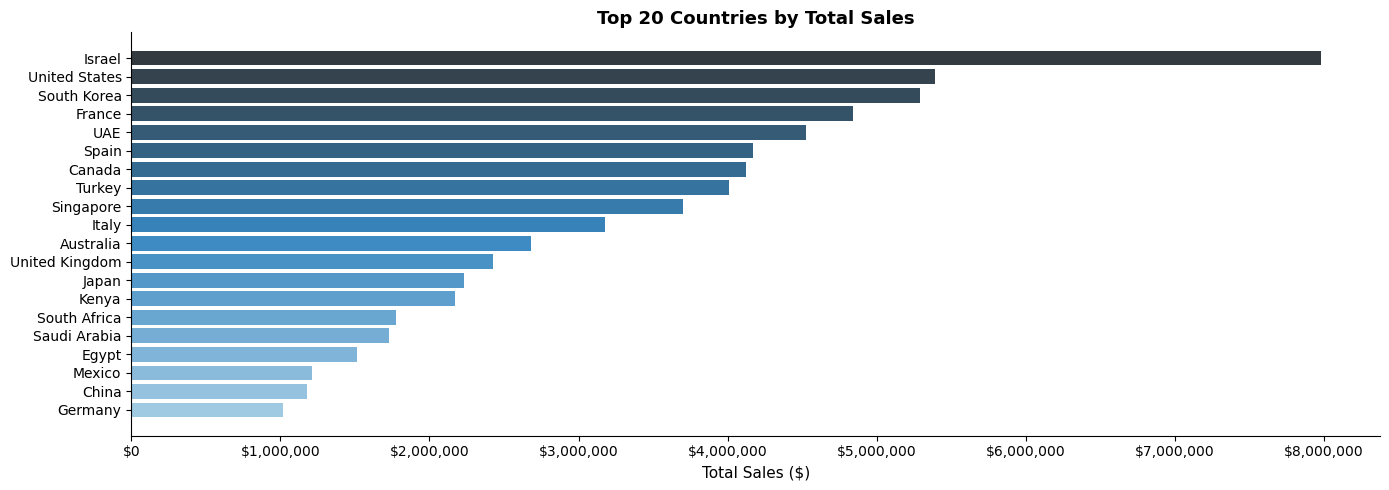

In [7]:
# Top 20 countries by total sales
top20 = df_country.nlargest(20, 'Total_Sales')

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(top20['Country'][::-1], top20['Total_Sales'][::-1],
               color=sns.color_palette('Blues_d', 20))
ax.set_xlabel('Total Sales ($)', fontsize=11)
ax.set_title('Top 20 Countries by Total Sales', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## Step 6 — Preprocess for K-Prototypes

K-Prototypes requires:
- **Numerical columns → StandardScaled** (so no single feature dominates distance)
- **Categorical columns → string dtype** (the library handles distance internally)
- You must pass the **column indices of categoricals** to the fit call

In [8]:
# Define feature sets
NUM_COLS = ['Total_Sales', 'Total_Profit', 'Total_Quantity',
            'Avg_Discount', 'Profit_Margin', 'Avg_Order_Value']

CAT_COLS = ['Region', 'Top_Segment', 'Top_Category']

# Drop rows with NaN (edge case: countries with zero sales)
df_model = df_country[['Country'] + NUM_COLS + CAT_COLS].dropna().copy()
df_model[CAT_COLS] = df_model[CAT_COLS].astype(str)

# Scale numerical features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df_model[NUM_COLS])

# Concatenate into final matrix
# K-Prototypes expects: [num_cols | cat_cols]
X_cat = df_model[CAT_COLS].values
X = np.hstack([X_num_scaled, X_cat])

# Track which column indices are categorical (0-indexed from left)
cat_col_indices = list(range(len(NUM_COLS), len(NUM_COLS) + len(CAT_COLS)))

print(f"Feature matrix shape : {X.shape}")
print(f"Numerical cols       : {NUM_COLS}")
print(f"Categorical cols     : {CAT_COLS}")
print(f"Cat column indices   : {cat_col_indices}")

Feature matrix shape : (27, 9)
Numerical cols       : ['Total_Sales', 'Total_Profit', 'Total_Quantity', 'Avg_Discount', 'Profit_Margin', 'Avg_Order_Value']
Categorical cols     : ['Region', 'Top_Segment', 'Top_Category']
Cat column indices   : [6, 7, 8]


## Step 7 — Elbow Method to Find Optimal K

We iterate K from 2 to 10, record the **inertia (total cost)** at each K,  
and look for the "elbow" — the point where adding more clusters yields diminishing returns.

⚠️ K-Prototypes is non-deterministic. We run each K **3 times** and take the minimum cost (same approach as sklearn's `n_init`).

In [11]:
# -----------------------------------------------------------------
# Dynamically cap K so it never approaches the sample count
# -----------------------------------------------------------------
n_countries = len(df_model)
MAX_K       = min(10, n_countries // 2)   # never let K >= n_samples / 2
K_RANGE     = range(2, MAX_K + 1)
N_INIT      = 3
GAMMA       = None

costs       = []
valid_ks    = []

print(f"Countries in model : {n_countries}")
print(f"Searching K range  : 2 → {MAX_K}\n")

for k in K_RANGE:
    best_cost = np.inf
    success   = False
    for seed in range(N_INIT):
        try:
            kp = KPrototypes(n_clusters=k, init='Huang', n_init=1,
                             verbose=0, random_state=seed, gamma=GAMMA)
            kp.fit(X, categorical=cat_col_indices)
            if kp.cost_ < best_cost:
                best_cost = kp.cost_
            success = True
        except ValueError as e:
            print(f"  K={k} seed={seed} skipped → {e}")

    if success:
        costs.append(best_cost)
        valid_ks.append(k)
        print(f"  K={k}  →  cost = {best_cost:,.2f}")
    else:
        print(f"  K={k}  →  all seeds failed, excluded from elbow")

print("\nDone ✅")

Countries in model : 27
Searching K range  : 2 → 10

  K=2  →  cost = 117.88
  K=3  →  cost = 98.31
  K=4  →  cost = 80.94
  K=5  →  cost = 70.54
  K=6  →  cost = 57.85
  K=7  →  cost = 58.33
  K=8  →  cost = 51.65
  K=9  →  cost = 42.21
  K=10  →  cost = 35.83

Done ✅


📍 Auto-detected optimal K = 6


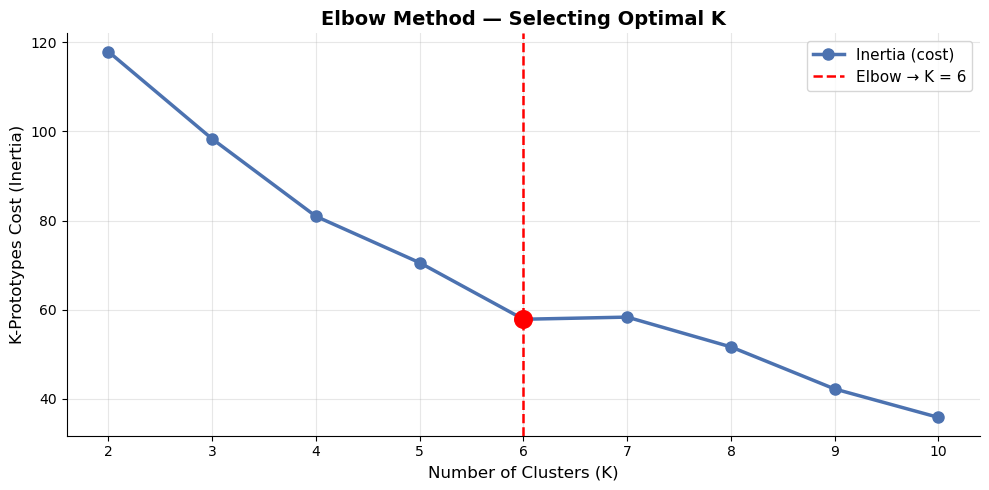

In [12]:
costs_arr = np.array(costs)

# Need at least 3 valid K points for second derivative
if len(costs_arr) >= 3:
    deltas    = np.diff(costs_arr)
    accel     = np.diff(deltas)
    elbow_idx = np.argmax(accel)
    optimal_k = valid_ks[elbow_idx + 1]   # +1 because diff loses one element
else:
    # Fallback: just pick the middle of valid range
    optimal_k = valid_ks[len(valid_ks) // 2]
    print("⚠️  Too few K points for second derivative — picking middle K")

print(f"📍 Auto-detected optimal K = {optimal_k}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(valid_ks, costs, 'o-', linewidth=2.5,
        markersize=8, color='#4C72B0', label='Inertia (cost)')
ax.axvline(optimal_k, color='red', linestyle='--', linewidth=1.8,
           label=f'Elbow → K = {optimal_k}')
ax.scatter([optimal_k], [costs[valid_ks.index(optimal_k)]],
           s=160, zorder=5, color='red')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('K-Prototypes Cost (Inertia)', fontsize=12)
ax.set_title('Elbow Method — Selecting Optimal K', fontsize=14, fontweight='bold')
ax.set_xticks(valid_ks)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8 — Fit Final K-Prototypes Model

In [13]:
FINAL_K = optimal_k   # override manually here if elbow plot tells a different story

kp_final = KPrototypes(n_clusters=FINAL_K, init='Huang',
                        n_init=5, verbose=0, random_state=42, gamma=GAMMA)
clusters = kp_final.fit_predict(X, categorical=cat_col_indices)

df_model = df_model.copy()
df_model['Cluster'] = clusters

print(f"Final model fitted  : K = {FINAL_K}")
print(f"Final cost          : {kp_final.cost_:,.2f}")
print(f"Gamma used          : {kp_final.gamma:.4f}")
print("\nCluster sizes:")
print(df_model['Cluster'].value_counts().sort_index())

Final model fitted  : K = 6
Final cost          : 55.52
Gamma used          : 0.5000

Cluster sizes:
Cluster
0    6
1    3
2    3
3    8
4    5
5    2
Name: count, dtype: int64


## Step 9 — Cluster Profiles

What does each cluster *mean* in business terms?

In [14]:
# ---- Numerical profile per cluster ----
profile_num = df_model.groupby('Cluster')[NUM_COLS].mean().round(2)
profile_num['n_countries'] = df_model.groupby('Cluster')['Country'].count()

# ---- Categorical mode per cluster ----
profile_cat = df_model.groupby('Cluster')[CAT_COLS].agg(safe_mode)

print("=" * 70)
print("CLUSTER NUMERICAL PROFILE (means)")
print("=" * 70)
print(profile_num.to_string())

print("\n" + "=" * 70)
print("CLUSTER CATEGORICAL PROFILE (dominant value)")
print("=" * 70)
print(profile_cat.to_string())

CLUSTER NUMERICAL PROFILE (means)
         Total_Sales  Total_Profit  Total_Quantity  Avg_Discount  Profit_Margin  Avg_Order_Value  n_countries
Cluster                                                                                                      
0         3979270.95     479596.13          4659.0          0.14           0.12          2446.18            6
1         3911510.54     475667.84          2543.0          0.13           0.12          4237.76            3
2          635214.13      80619.64           968.0          0.14           0.13          2120.59            3
3         1074467.40     126074.97          2984.0          0.14           0.12           973.75            8
4         1862729.03     219795.23          1183.0          0.14           0.12          4392.03            5
5         6634075.95     773247.47          3959.0          0.14           0.12          4544.80            2

CLUSTER CATEGORICAL PROFILE (dominant value)
                Region Top_Segment     T

In [ ]:
# Normalise numeric profile for heatmap (0–1 scale per feature)
profile_norm = (profile_num[NUM_COLS] - profile_num[NUM_COLS].min()) / \
               (profile_num[NUM_COLS].max() - profile_num[NUM_COLS].min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, max(4, FINAL_K * 0.8)))
sns.heatmap(profile_norm, annot=profile_num[NUM_COLS], fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Relative intensity (0–1)'},
            annot_kws={'size': 9})
ax.set_title('Cluster Profile Heatmap — Numerical Features',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Cluster', fontsize=11)
ax.set_yticklabels([f'Cluster {i}' for i in range(FINAL_K)], rotation=0)
ax.set_xticklabels(NUM_COLS, rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Step 10 — PCA Visualisation (2D)

PCA projects the high-dimensional feature space down to 2D so we can *see* the clusters.  
We run PCA only on the **scaled numerical features** (PCA needs numbers).

PC1 explains 46.9% of variance
PC2 explains 20.8% of variance
Total       67.7%


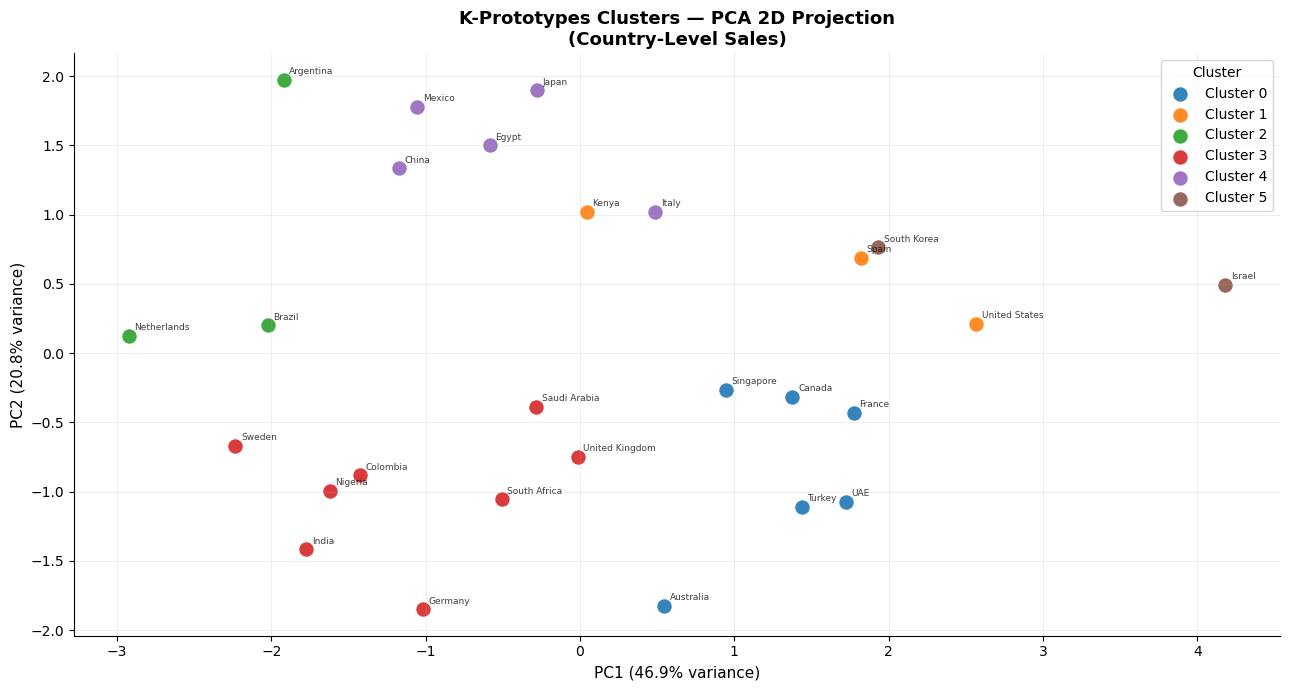

In [15]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_num_scaled[:len(df_model)])

explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]*100:.1f}% of variance")
print(f"PC2 explains {explained[1]*100:.1f}% of variance")
print(f"Total       {sum(explained)*100:.1f}%")

df_pca = pd.DataFrame(coords, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters
df_pca['Country'] = df_model['Country'].values

# ---- Scatter plot ----
palette = sns.color_palette('tab10', FINAL_K)

fig, ax = plt.subplots(figsize=(13, 7))
for cid in range(FINAL_K):
    mask = df_pca['Cluster'] == cid
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               s=120, color=palette[cid], label=f'Cluster {cid}',
               edgecolors='white', linewidth=0.6, alpha=0.9)

# Annotate each point with country name
for _, row in df_pca.iterrows():
    ax.annotate(row['Country'],
                xy=(row['PC1'], row['PC2']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=6.5, alpha=0.75)

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('K-Prototypes Clusters — PCA 2D Projection\n(Country-Level Sales)',
             fontsize=13, fontweight='bold')
ax.legend(title='Cluster', fontsize=10, title_fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Step 11 — Countries per Cluster

In [16]:
print("Countries assigned to each cluster:\n")
for cid in sorted(df_model['Cluster'].unique()):
    countries_in = df_model.loc[df_model['Cluster'] == cid, 'Country'].tolist()
    dominant_cat = profile_cat.loc[cid].to_dict()
    dominant_num = profile_num.loc[cid, ['Total_Sales','Profit_Margin']].to_dict()
    print(f"── Cluster {cid} ({len(countries_in)} countries) ──")
    print(f"   Dominant: Region={dominant_cat['Region']}, "
          f"Segment={dominant_cat['Top_Segment']}, "
          f"Category={dominant_cat['Top_Category']}")
    print(f"   Avg Sales=${dominant_num['Total_Sales']:,.0f}, "
          f"Margin={dominant_num['Profit_Margin']:.1%}")
    print(f"   Countries: {', '.join(sorted(countries_in))}")
    print()

Countries assigned to each cluster:

── Cluster 0 (6 countries) ──
   Dominant: Region=Asia Pacific, Segment=Consumer, Category=Technology
   Avg Sales=$3,979,271, Margin=12.0%
   Countries: Australia, Canada, France, Singapore, Turkey, UAE

── Cluster 1 (3 countries) ──
   Dominant: Region=Africa, Segment=Consumer, Category=Technology
   Avg Sales=$3,911,511, Margin=12.0%
   Countries: Kenya, Spain, United States

── Cluster 2 (3 countries) ──
   Dominant: Region=South America, Segment=Consumer, Category=Office Supplies
   Avg Sales=$635,214, Margin=13.0%
   Countries: Argentina, Brazil, Netherlands

── Cluster 3 (8 countries) ──
   Dominant: Region=Europe, Segment=Consumer, Category=Technology
   Avg Sales=$1,074,467, Margin=12.0%
   Countries: Colombia, Germany, India, Nigeria, Saudi Arabia, South Africa, Sweden, United Kingdom

── Cluster 4 (5 countries) ──
   Dominant: Region=Asia Pacific, Segment=Consumer, Category=Technology
   Avg Sales=$1,862,729, Margin=12.0%
   Countries: Ch

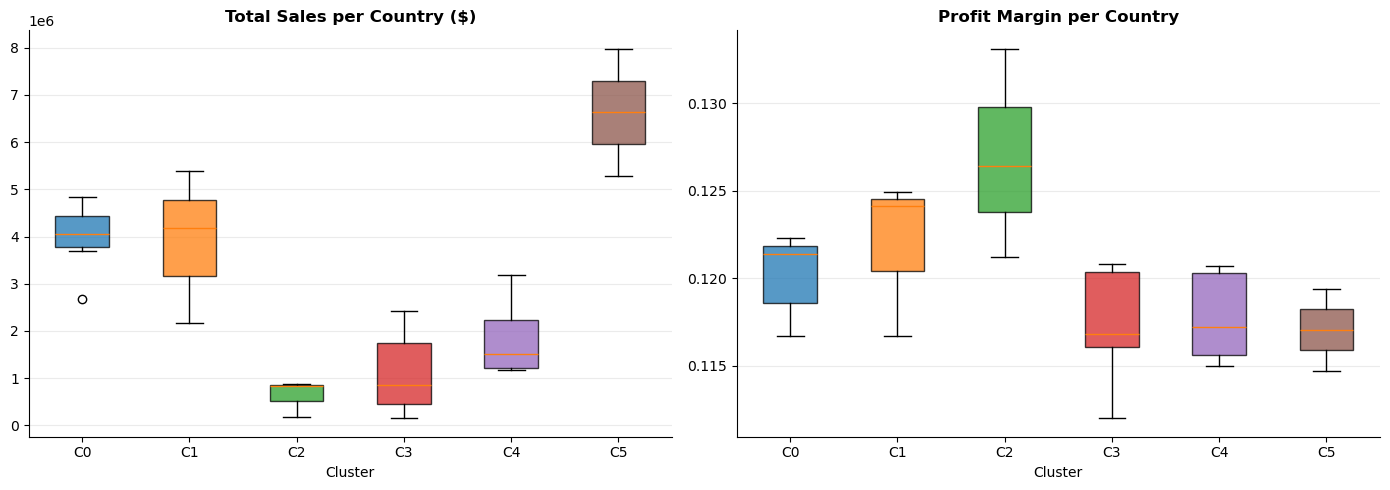

In [17]:
# Sales and Profit distribution per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['Total_Sales', 'Profit_Margin'],
                           ['Total Sales per Country ($)', 'Profit Margin per Country']):
    data_by_cluster = [df_model.loc[df_model['Cluster'] == c, col].values
                       for c in range(FINAL_K)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    labels=[f'C{c}' for c in range(FINAL_K)])
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

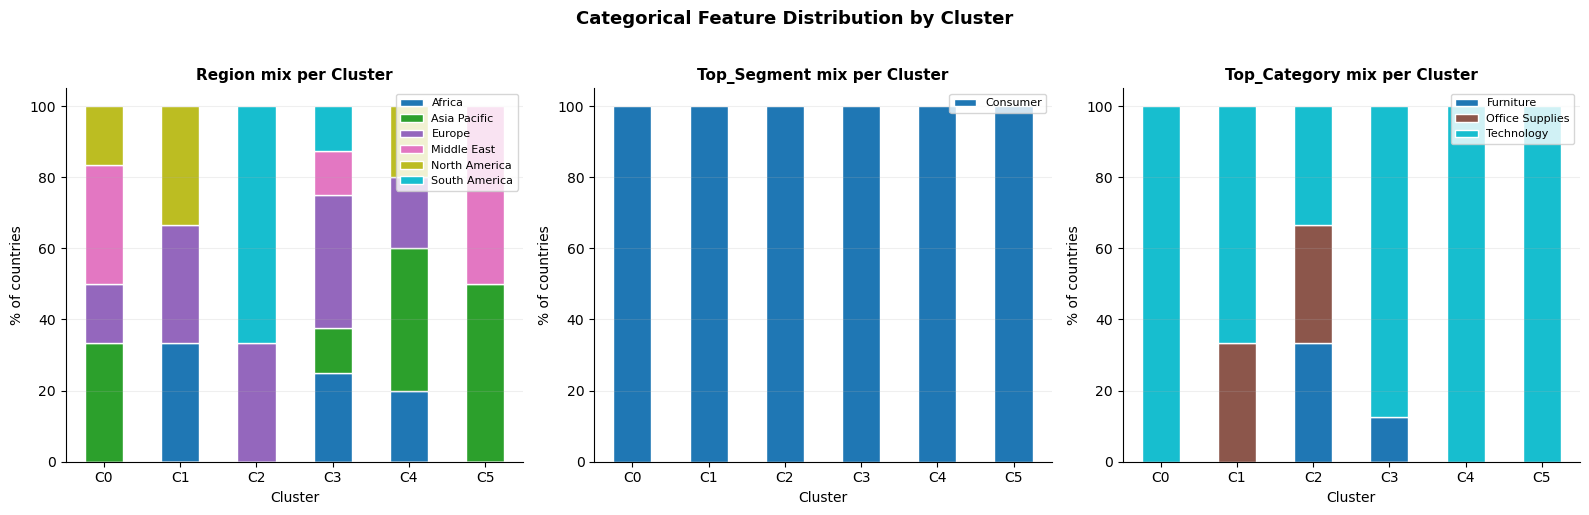

In [18]:
# Categorical distribution: which regions/segments dominate each cluster?
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(16, 5))

for ax, cat_col in zip(axes, CAT_COLS):
    pivot = pd.crosstab(df_model['Cluster'], df_model[cat_col], normalize='index') * 100
    pivot.plot(kind='bar', ax=ax, stacked=True,
               colormap='tab10', legend=True, rot=0, edgecolor='white')
    ax.set_title(f'{cat_col} mix per Cluster', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('% of countries')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_xticklabels([f'C{i}' for i in range(FINAL_K)])
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Categorical Feature Distribution by Cluster',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 12 — Business Interpretation Template

Use the cluster profiles above to label each cluster. Typical patterns you may see:

| Pattern | Signature |
|---|---|
| **High-value markets** | High Sales, High Profit Margin, Technology dominant |
| **Volume markets** | High Quantity, Low Margin, Consumer segment |
| **Discount-sensitive** | High Avg_Discount, Low Margin |
| **Emerging/small markets** | Low Sales, Low Orders, Office Supplies dominant |
| **Corporate B2B** | Corporate segment dominant, Moderate Sales, High Margin |

### What to do next:
- **Cluster with high sales + high margin** → defend, invest in retention  
- **Cluster with high volume + low margin** → reduce discounts, upsell high-margin SKUs  
- **Cluster with low sales** → pilot campaign, evaluate market entry ROI  
- **Cluster with high discount** → pricing strategy review

In [ ]:
# Export the enriched country-cluster table
output = df_model[['Country', 'Cluster'] + NUM_COLS + CAT_COLS].sort_values(
    ['Cluster', 'Total_Sales'], ascending=[True, False]
)
output.to_csv('country_clusters.csv', index=False)
print("Saved → country_clusters.csv")
output.head(15)

---
### Key Takeaways

1. **K-Prototypes is K-Means + K-Modes** — it handles mixed data natively without one-hot encoding
2. **Gamma (γ)** controls the weight between numerical and categorical distance — auto-selected here via Cao initialisation
3. **Elbow method** on K-Prototypes cost is the same intuition as K-Means — look for where the cost curve bends
4. **PCA projection** is only for visualisation — the actual clustering used all 9 features
5. Cluster labels are arbitrary (0, 1, 2...) — **business meaning comes from profiling**, not the number